In [1]:
from trainModel import trainModel
from Dataset import ModelDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, confusion_matrix, accuracy_score, precision_recall_curve
import pandas as pd
import os
from generateSplits import generateSplits
from torch.utils.data import DataLoader
import torch,gc
import numpy as np
from typing import Literal, Callable, Iterator
from functools import partial
import matplotlib.pyplot as plt

In [2]:
best_params = {'lr': 0.010203264127576701, 'weight_decay': 0.004617603477095672, 'batch_size': 8, 'optimiser_name': 'Adam'}

In [3]:
DATASET_PATH = r"E:\SRP\SRP-2025-Project\ISPY2_T0_T3_DCE_npz"
MODEL_SAVE_PATH = r"E:\SRP\SRP-2025-Project\model_weights"

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dataset_df = pd.read_excel(r"e:\SRP\ISPY2-Data-Collector\ISPY2-Imaging-Cohort-1-Clinical-Data.xlsx")
dataset_df = dataset_df.set_index("Patient_ID",drop=True)
dataset_df = dataset_df.loc[dataset_df.index.isin([int(os.path.splitext(fname)[0].replace("ISPY2-","")) for fname in os.listdir(DATASET_PATH)]),["HR","HER2","pCR"]]

train_df, test_df = generateSplits(dataset_df,0.2,seed=2008)
train_dataset = ModelDataset(train_df,DATASET_PATH,{0:1,1:2},loading_bar=True)
train_loader = DataLoader(train_dataset,batch_size=best_params["batch_size"],shuffle=True)
test_dataset = ModelDataset(test_df, DATASET_PATH, {0:1,1:1}, loading_bar=True)
test_loader =DataLoader(test_dataset, batch_size=best_params["batch_size"])
positive_ratio = (test_df["pCR"].value_counts()[1])/len(test_df)



100%|███████████████████████████████████████████████████████████████████████████████████████| 342/342 [01:33<00:00,  3.66it/s]


Dataset initialised with 463 entries.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 86/86 [00:24<00:00,  3.44it/s]

Dataset initialised with 86 entries.


In [4]:
def get_scores(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],mode:Literal["preNac","both"]="preNac"):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,mode)
            else:
                logits = model(T0_volumes,T3_volumes,mols,mode)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return y_true,y_score

def score_to_pred(y_true,y_score):
    fpr,tpr,thresholds = roc_curve(y_true,y_score)
    youden_index = tpr-fpr
    best_idx = np.argmax(youden_index)
    best_threshold = thresholds[best_idx]
    y_pred = np.array(y_score)>=best_threshold
    return y_pred

In [5]:
def evaluate_roc_auc(model:torch.nn.Module,test_loader:DataLoader,combine_timepoints:bool,out_features:Literal[1,2],testKwargs:dict):
    model.eval()
    y_true=[]
    y_score=[]
    
    with torch.no_grad():
        for T0_volumes,T3_volumes,mols,labels in test_loader:
            T0_volumes = T0_volumes.to(device)
            T3_volumes = T3_volumes.to(device)
            mols = mols.to(device)
            labels = labels.to(device)
            if combine_timepoints:
                logits = model(torch.cat((T0_volumes,T3_volumes),dim=1),mols,**testKwargs)
            else:
                logits = model(T0_volumes,T3_volumes,mols,**testKwargs)
                
            if out_features == 1:
                score = torch.sigmoid(logits).squeeze()
            elif out_features == 2:
                score = torch.nn.functional.softmax(logits,dim=1)[:,1]
            y_true.extend(labels.cpu().numpy())
            y_score.extend(score.cpu().numpy())
    return float(roc_auc_score(y_true,y_score))

In [ ]:
def getTrainedModel(
    model: torch.nn.Module,
    combine_timepoints: bool,
    out_features: Literal[1, 2],
    loss_fn: Callable,
    trainKwargs: dict,
    testKwargs: dict,
    save:bool,
    filename:str,
):
    optimiser_class = partial(
        torch.optim.AdamW,
        lr=best_params["lr"],
        weight_decay=best_params["weight_decay"],
    )

    trainedModel, _ = trainModel(
        model=model,
        train_loader=train_loader,
        combine_timepoints=combine_timepoints,
        out_features=out_features,
        loss_fn=loss_fn,
        optimiser=optimiser_class(model.parameters()),
        num_epochs=30,
        val_loader=test_loader,
        score_fn=evaluate_roc_auc,
        score_name="ROC AUC",
        patience=10,
        trainKwargs=trainKwargs,
        testKwargs=testKwargs,
    )
    
    if save:
        torch.save(trainedModel.state_dict(), os.path.join(MODEL_SAVE_PATH, filename))
    
    return trainedModel


def plot(
    model:torch.nn.Module,
    test_loader,
    combine_timepoints:bool,
    out_features:Literal[1,2,],):
    
    y_true, y_score = get_scores(model,test_loader,combine_timepoints,out_features, mode = "preNac")
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)  
    
    # ---- Compute Youden Index ----
    youden = tpr - fpr                      # same as sensitivity + specificity - 1
    best_idx = np.argmax(youden)            # index of best threshold
    best_fpr = fpr[best_idx]
    best_tpr = tpr[best_idx]
    best_roc_thresholds = roc_thresholds[best_idx]
    
    
    
    plt.figure()
    plt.plot(fpr,tpr)
    plt.plot([0, 1], [0, 1], "--")
    # ---- Mark Youden point ----
    plt.scatter(best_fpr, best_tpr, color="red", s=50, zorder=3,
                label=f"Youden Index\nTPR={best_tpr:.3f}, FPR={best_fpr:.3f}")
    
     # ---- Set ticks at 0.1 increments ----
    plt.xticks(np.arange(0.0, 1.1, 0.1))
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve\nAUC = {roc_auc_score(y_true,y_score):.3f}")
    plt.grid()
    plt.legend()
    

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    plt.figure()
    plt.plot(recall,precision)
    plt.axhline(positive_ratio, color="gray", linestyle="--", label=f"Baseline AP = {positive_ratio:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve\nAverage Precision = {average_precision_score(y_true,y_score):.3f}")
    
    y_pred = score_to_pred(y_true,y_score)
    plt.figure()
    y_signed = np.array([score if pred==1 else -score for score, pred in zip(y_score, y_pred)])
    # Sort for better visualization
    idx = np.argsort(y_signed)
    y_sorted = y_signed[idx]
    labels_sorted = np.array(y_true)[idx]
    # Color by true label: blue = pCR, red = non-pCR
    colors = ["blue" if t==1 else "red" for t in labels_sorted]
    # Plot
    plt.figure(figsize=(8,5))
    plt.bar(range(len(y_sorted)), y_sorted, color=colors, width=0.8)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.ylabel("Predicted Score (positive = pCR, negative = non-pCR)")
    plt.ylim([min(y_sorted)*1.2, max(y_sorted)*1.2])
    plt.grid(False)
    plt.title("Predicted scores of participants in the validation set\nBlue = true pCR, Red = true non-pCR\nBars above 0 = predicted pCR, Bars below 0 = predicted non-pCR")

    
    

Epoch 0 Done. Average Loss=0.7255
ROC AUC=0.5955357142857142
Epoch 1 Done. Average Loss=0.6584
ROC AUC=0.5958333333333333
Epoch 2 Done. Average Loss=0.6756
ROC AUC=0.5791666666666667
Epoch 3 Done. Average Loss=0.6647
ROC AUC=0.5904761904761905
Epoch 4 Done. Average Loss=0.6616
ROC AUC=0.6
Epoch 5 Done. Average Loss=0.6613
ROC AUC=0.5857142857142857
Epoch 6 Done. Average Loss=0.6521
ROC AUC=0.5928571428571429
Epoch 7 Done. Average Loss=0.6542
ROC AUC=0.6089285714285715
Epoch 8 Done. Average Loss=0.6575
ROC AUC=0.6035714285714286
Epoch 9 Done. Average Loss=0.6558
ROC AUC=0.6080357142857143
Epoch 10 Done. Average Loss=0.6548
ROC AUC=0.5991071428571428
Epoch 11 Done. Average Loss=0.6526
ROC AUC=0.5895833333333333
Epoch 12 Done. Average Loss=0.6519
ROC AUC=0.593452380952381
Epoch 13 Done. Average Loss=0.6527
ROC AUC=0.5913690476190476
Epoch 14 Done. Average Loss=0.6504
ROC AUC=0.5958333333333333
Epoch 15 Done. Average Loss=0.6548
ROC AUC=0.5994047619047619
Epoch 16 Done. Average Loss=0.6554

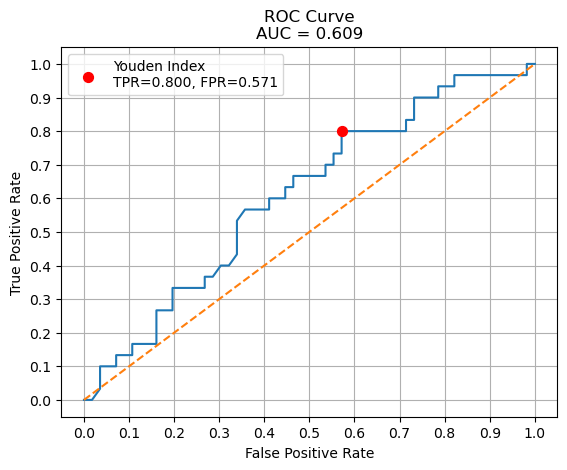

<Figure size 640x480 with 0 Axes>

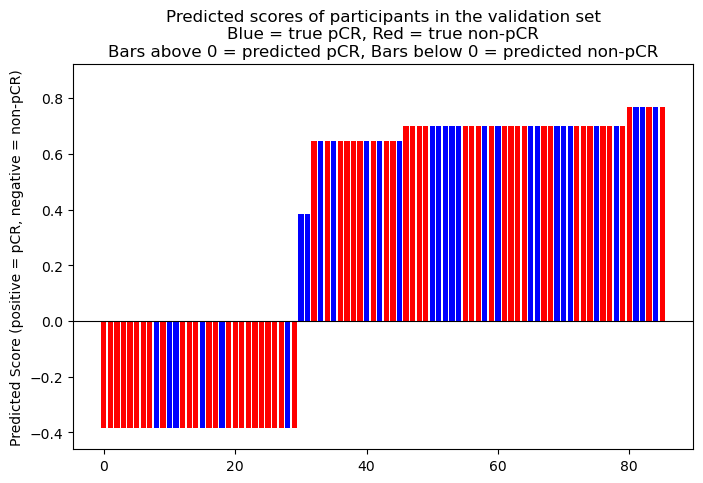

In [7]:
from models.MaxViTwithCAFusion import Model as MaxViTwithCAF

model = MaxViTwithCAF(
    partition_size=(1, 4, 4),
    downsample_depth_schedule=[True, True, False, False],
    fusion_feedforward_dim=256,
    mols_dim=32,
    hidden_fusion_dim=64,
).to(device)

trainedModel = getTrainedModel(
    model,
    combine_timepoints=False,
    out_features=1,
    loss_fn=torch.nn.BCEWithLogitsLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "MaxViTwithCAF_weights.pt"
)

plot(trainedModel, test_loader, combine_timepoints=False, out_features = 1)

In [ ]:
from models.CMC_Model.model import Model as CMCModel

model = CMCModel().to(device)

trainedModel = getTrainedModel(
    model,
    combine_timepoints=True,
    out_features=2,
    loss_fn=torch.nn.CrossEntropyLoss(),
    trainKwargs={"mode": "both"},
    testKwargs={"mode": "preNac"},
    save = True,
    filename = "CMCModel_weights.pt"
)

plot(trainedModel, test_loader, combine_timepoints=True, out_features = 2)

Epoch 0 Done. Average Loss=44.0632
ROC AUC=0.5958333333333333
Epoch 1 Done. Average Loss=1.9602
ROC AUC=0.5059523809523809
Epoch 2 Done. Average Loss=0.6866
ROC AUC=0.46398809523809526


KeyboardInterrupt: 